# Hierarchical Gaussians: Minimal SSNAL Warm-Start Thresholds

Minimal experiment notebook that:
- runs SSNAL from warm-starts (`data`, `pdhg`, `gcn`, `gat`) across hierarchical-gaussians lambda values
- visualizes convergence (mean PDG vs SSNAL iteration)
- prints threshold first-hit iteration summary (median + hit rate)


In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / 'notebooks').exists():
    pass
elif PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError('Run this notebook from repository root or notebooks directory.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import algorithms as alg
import datasets.datasets as Datasets
import losses.losses as Losses
import models.models as Models

torch.set_default_dtype(torch.float32)
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PROJECT_ROOT={PROJECT_ROOT}')
print(f'DEVICE={DEVICE}')
print(f'pandas_version={pd.__version__}')


/Users/chester/Documents/tmp/cc-net/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT=/Users/chester/Documents/tmp/cc-net
DEVICE=cpu
pandas_version=3.0.2


In [2]:
# Notebook knobs
CONFIG_ROOT = PROJECT_ROOT / 'configs' / 'single-runs' / 'hierarchical-gaussians'
CHECKPOINT_ROOT = PROJECT_ROOT / 'models-cc'

FAMILIES = {
    'pdhg': {'label': 'PDHG-Net', 'config_subdir': 'pdhg', 'checkpoint_subdir': 'PDHG'},
    'gcn': {'label': 'GCN', 'config_subdir': 'gcn-baselines', 'checkpoint_subdir': 'GCN'},
    'gat': {'label': 'GAT', 'config_subdir': 'gat-baselines', 'checkpoint_subdir': 'GAT'},
}

WARMSTART_METHODS = ['data', 'pdhg', 'gcn', 'gat']
METHOD_LABELS = {
    'data': 'Data init',
    'pdhg': 'PDHG-Net init',
    'gcn': 'GCN init',
    'gat': 'GAT init',
}

THRESHOLDS = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
MAX_GRAPHS = 50
SSNAL_ITERS = 200
SSNAL_TAU = 0.35
SSNAL_SIGMA = 0.5

print('CONFIG_ROOT:', CONFIG_ROOT)
print('CHECKPOINT_ROOT:', CHECKPOINT_ROOT)
print('MAX_GRAPHS:', MAX_GRAPHS)
print('SSNAL_ITERS:', SSNAL_ITERS)


CONFIG_ROOT: /Users/chester/Documents/tmp/cc-net/configs/single-runs/hierarchical-gaussians
CHECKPOINT_ROOT: /Users/chester/Documents/tmp/cc-net/models-cc
MAX_GRAPHS: 50
SSNAL_ITERS: 200


In [3]:
def load_yaml_config(path: Path) -> dict:
    with open(path, 'r') as f:
        return yaml.safe_load(f)


def _lam_tokens(lam: float) -> list[str]:
    x = float(lam)
    vals = {str(lam), f'{x}', f'{x:.1f}', f'{x:.2f}', f'{x:.3f}'}
    if x.is_integer():
        vals.add(str(int(x)))
        vals.add(f'{int(x)}.0')
    return sorted(vals)


def _dedupe_paths(paths: list[Path]) -> list[Path]:
    out = []
    seen = set()
    for p in paths:
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out


def resolve_config_path(model_family: str, lam: float, config_root: Path) -> Path:
    family_info = FAMILIES[model_family]
    family_dir = config_root / family_info['config_subdir']

    candidates = []
    for tok in _lam_tokens(lam):
        p = family_dir / f'lam{tok}.yaml'
        if p.exists():
            candidates.append(p)

    deduped = _dedupe_paths(candidates)
    if len(deduped) == 0:
        raise FileNotFoundError(f'No config found for family={model_family}, lam={lam}')
    if len(deduped) > 1:
        raise RuntimeError(
            f'Ambiguous configs for family={model_family}, lam={lam}:\n' + '\n'.join(map(str, deduped))
        )
    return deduped[0]


def resolve_checkpoint_path(model_family: str, lam: float, checkpoint_root: Path) -> Path:
    family_info = FAMILIES[model_family]
    family_dir = checkpoint_root / family_info['checkpoint_subdir']
    tokens = _lam_tokens(lam)

    candidates = []
    if model_family in {'pdhg', 'gcn'}:
        for tok in tokens:
            p = family_dir / f'lam{tok}.pt'
            if p.exists():
                candidates.append(p)
    elif model_family == 'gat':
        for tok in tokens:
            candidates.extend(sorted(family_dir.glob(f'*lam{tok}_*/final.pt')))
            candidates.extend(sorted(family_dir.glob(f'*lam{tok}/final.pt')))
    else:
        raise ValueError(f'Unknown model_family={model_family}')

    deduped = _dedupe_paths(candidates)
    if len(deduped) == 0:
        raise FileNotFoundError(f'No checkpoint found for family={model_family}, lam={lam}')
    if len(deduped) > 1:
        raise RuntimeError(
            f'Ambiguous checkpoints for family={model_family}, lam={lam}:\n' + '\n'.join(map(str, deduped))
        )
    return deduped[0]


def load_state_dict_compat(path: Path) -> dict:
    state = torch.load(path, map_location='cpu')
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    if not isinstance(state, dict):
        raise TypeError(f'Unsupported checkpoint object type: {type(state)} at {path}')

    state = dict(state)
    keys_to_remove = set()
    remap = {}
    for key, value in list(state.items()):
        if '.lin_src.weight' in key:
            new_key = key.replace('.lin_src.weight', '.lin.weight')
            dst_key = key.replace('.lin_src.weight', '.lin_dst.weight')
            if dst_key in state:
                dst_value = state[dst_key]
                if not torch.equal(value, dst_value):
                    max_diff = float((value - dst_value).abs().max())
                    raise ValueError(
                        f'Cannot safely remap {key}: lin_src and lin_dst differ (max_diff={max_diff})'
                    )
                keys_to_remove.add(dst_key)
            remap[new_key] = value
            keys_to_remove.add(key)

    if remap:
        for k in keys_to_remove:
            state.pop(k, None)
        state.update(remap)

    return state


def instantiate_model(model_cfg: dict, device: torch.device) -> torch.nn.Module:
    model_class = getattr(Models, model_cfg['model'])
    model = model_class(**model_cfg['cfg']).float().to(device)
    model.eval()
    return model


@torch.no_grad()
def forward_single_pass(model: torch.nn.Module, data, device: torch.device):
    data = data.to(device)
    x = data.x.float()
    src, dst = data.edge_index.long()
    e0 = x[src] - x[dst]
    U, P = model(
        h=x,
        e=e0.float(),
        edge_index=data.edge_index.long(),
        w=data.edge_attr.float(),
        x=x,
    )
    return U, P


def run_ssnal_history(
    X: torch.Tensor,
    edge_index: torch.Tensor,
    w: torch.Tensor,
    lam: float,
    iters: int,
    tau: float,
    sigma: float,
    U0: torch.Tensor,
    P0: torch.Tensor,
):
    src, dst = edge_index.long()
    n, _ = X.shape

    sigma_k = max(float(sigma), 1e-6)
    Xk = U0.to(dtype=X.dtype, device=X.device).clone()
    sqrtw = w.sqrt().clamp_min(1e-12).view(-1, 1)
    Zk = sqrtw * P0.to(dtype=X.dtype, device=X.device)

    hist = {'pdg': []}
    max_newton_iters = 30
    cg_max_iters = min(400, max(40, 2 * n))

    for k in range(iters):
        alm_epsilon_k = min(1e-2, 1.0 / float((k + 1) ** 2))
        subproblem_tol = alm_epsilon_k / max(1.0, sigma_k**0.5)

        Xk = alg._ssncg_subproblem(
            A=X,
            src=src,
            dst=dst,
            w=w,
            lam=lam,
            sigma_k=sigma_k,
            Zk=Zk,
            X0=Xk,
            tau=tau,
            max_newton_iters=max_newton_iters,
            cg_max_iters=cg_max_iters,
            stopping_tol=subproblem_tol,
        )

        Dk = alg._graph_difference(Xk, src, dst) + Zk / sigma_k
        Uk = alg._weighted_group_l2_shrinkage(Dk, (lam * w) / sigma_k)
        primal_residual = alg._graph_difference(Xk, src, dst) - Uk
        Zk = Zk + sigma_k * primal_residual
        Pk = Zk / sqrtw

        hist['pdg'].append(float(Losses.energy_pdg(Xk, X, Pk, src, dst, w, lam)))

    return Xk, Pk, hist


def first_hit(values: list[float], threshold: float) -> float:
    arr = np.asarray(values, dtype=np.float64)
    idx = np.where(np.isfinite(arr) & (arr <= threshold))[0]
    return float(idx[0] + 1) if len(idx) > 0 else np.nan


In [4]:
# Load canonical lambda list from PDHG configs and build one shared dataset
pdhg_cfg_dir = CONFIG_ROOT / FAMILIES['pdhg']['config_subdir']
cfg_paths = sorted(pdhg_cfg_dir.glob('*.yaml'))
if len(cfg_paths) == 0:
    raise FileNotFoundError(f'No YAML files found in {pdhg_cfg_dir}')

cfgs_by_lambda = {}
for cfg_path in cfg_paths:
    cfg = load_yaml_config(cfg_path)
    lam = float(cfg['model_config']['cfg']['lam'])
    cfgs_by_lambda[lam] = cfg

lambdas = sorted(cfgs_by_lambda.keys())
canonical_cfg = cfgs_by_lambda[lambdas[0]]

dataset_cfg = canonical_cfg['dataset']
dataset_ctor = getattr(Datasets, dataset_cfg['type'])
eval_dataset = dataset_ctor(dict(dataset_cfg['params']))
if MAX_GRAPHS is not None:
    eval_dataset = eval_dataset[: int(MAX_GRAPHS)]

print('Lambdas:', lambdas)
print('Evaluation graphs:', len(eval_dataset))
data0 = eval_dataset[0]
print(f"Graph[0] nodes={data0.x.shape[0]}, edges={data0.edge_index.shape[1]}, feat_dim={data0.x.shape[1]}")


100%|██████████| 1000/1000 [00:00<00:00, 2426.26it/s]

Lambdas: [0.001, 0.01, 0.1, 1.0, 10.0]
Evaluation graphs: 50
Graph[0] nodes=80, edges=720, feat_dim=2


In [5]:
# Resolve checkpoints and cache loaded models for learned warm-starts
resolved_ckpts = {}
for method in ['pdhg', 'gcn', 'gat']:
    resolved_ckpts[method] = {}
    for lam in lambdas:
        resolved_ckpts[method][lam] = resolve_checkpoint_path(method, lam, CHECKPOINT_ROOT)

model_cache = {}
for method in ['pdhg', 'gcn', 'gat']:
    for lam in lambdas:
        cfg_path = resolve_config_path(method, lam, CONFIG_ROOT)
        cfg = load_yaml_config(cfg_path)
        model_cfg = cfg['model_config']
        model = instantiate_model(model_cfg, DEVICE)
        state = load_state_dict_compat(resolved_ckpts[method][lam])
        model.load_state_dict(state, strict=True)
        model_cache[(method, lam)] = model

print('Loaded model cache entries:', len(model_cache))


Loaded model cache entries: 15


In [6]:
# Main evaluation loop
iter_records = []
first_hit_records = []

for lam in lambdas:
    for graph_idx in tqdm(range(len(eval_dataset)), desc=f'SSNAL warm-start eval lambda={lam:g}'):
        data = eval_dataset[graph_idx].to(DEVICE)
        X = data.x.float()
        edge_index = data.edge_index.long()
        w = data.edge_attr.float()
        E = edge_index.shape[1]
        D = X.shape[1]

        for method in WARMSTART_METHODS:
            if method == 'data':
                U0 = X.clone()
                P0 = torch.zeros((E, D), dtype=X.dtype, device=DEVICE)
            else:
                model = model_cache[(method, lam)]
                U0, P0 = forward_single_pass(model, data, DEVICE)

            _, _, hist = run_ssnal_history(
                X=X,
                edge_index=edge_index,
                w=w,
                lam=float(lam),
                iters=int(SSNAL_ITERS),
                tau=float(SSNAL_TAU),
                sigma=float(SSNAL_SIGMA),
                U0=U0,
                P0=P0,
            )

            for k, pdg_val in enumerate(hist['pdg'], start=1):
                iter_records.append({
                    'method': method,
                    'label': METHOD_LABELS[method],
                    'lambda': lam,
                    'graph_idx': graph_idx,
                    'iter': k,
                    'pdg': pdg_val,
                })

            for thr in THRESHOLDS:
                first_hit_records.append({
                    'method': method,
                    'label': METHOD_LABELS[method],
                    'lambda': lam,
                    'graph_idx': graph_idx,
                    'threshold': thr,
                    'first_hit_iter': first_hit(hist['pdg'], thr),
                })

iter_df = pd.DataFrame(iter_records)
first_hit_df = pd.DataFrame(first_hit_records)

if iter_df.empty or first_hit_df.empty:
    raise RuntimeError('Expected non-empty result tables.')

expected_groups = len(WARMSTART_METHODS) * len(lambdas) * len(THRESHOLDS)
actual_groups = first_hit_df.groupby(['method', 'lambda', 'threshold']).ngroups
assert actual_groups == expected_groups, f'Expected {expected_groups} grouped rows, got {actual_groups}'

print('Evaluation complete.')
print('iter_df rows:', len(iter_df))
print('first_hit_df rows:', len(first_hit_df))


SSNAL warm-start eval lambda=10: 100%|██████████| 50/50 [01:04<00:00,  1.29s/it]

Evaluation complete.
iter_df rows: 200000
first_hit_df rows: 6000


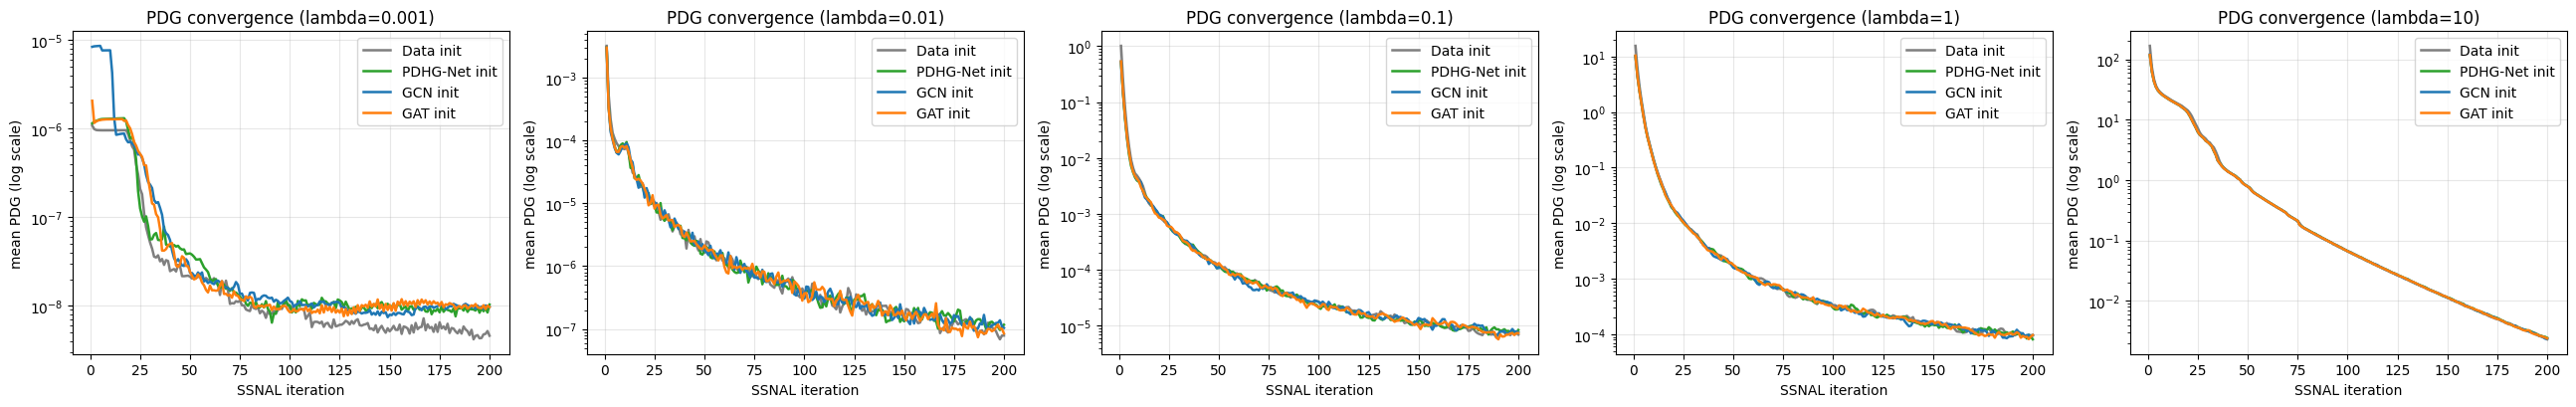

In [7]:
# Convergence plots: mean PDG vs SSNAL iteration (one panel per lambda)
fig, axes = plt.subplots(1, len(lambdas), figsize=(5.2 * len(lambdas), 4.2), squeeze=False)
axes = axes.ravel()

colors = {
    'data': 'tab:gray',
    'pdhg': 'tab:green',
    'gcn': 'tab:blue',
    'gat': 'tab:orange',
}

for ax, lam in zip(axes, lambdas):
    sub = iter_df[iter_df['lambda'] == lam]
    grouped = (
        sub.groupby(['method', 'iter'], as_index=False)
        .agg(pdg_mean=('pdg', 'mean'))
    )

    for method in WARMSTART_METHODS:
        g = grouped[grouped['method'] == method].sort_values('iter')
        ax.semilogy(
            g['iter'],
            g['pdg_mean'],
            label=METHOD_LABELS[method],
            color=colors[method],
            linewidth=1.8,
        )

    ax.set_title(f'PDG convergence (lambda={lam:g})')
    ax.set_xlabel('SSNAL iteration')
    ax.set_ylabel('mean PDG (log scale)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()


In [8]:
# Threshold table: median first-hit iterations + hit-rate
threshold_summary = (
    first_hit_df
    .groupby(['method', 'label', 'lambda', 'threshold'], as_index=False)
    .agg(
        n_total=('first_hit_iter', 'size'),
        n_hits=('first_hit_iter', lambda s: int(s.notna().sum())),
        hit_rate=('first_hit_iter', lambda s: float(s.notna().mean())),
        median_first_hit=('first_hit_iter', 'median'),
    )
    .sort_values(['label', 'lambda', 'threshold'])
    .reset_index(drop=True)
)

expected_rows = len(WARMSTART_METHODS) * len(lambdas) * len(THRESHOLDS)
assert len(threshold_summary) == expected_rows, f'Expected {expected_rows} rows, got {len(threshold_summary)}'

display(threshold_summary)


,method,label,lambda,threshold,n_total,n_hits,hit_rate,median_first_hit
0,data,Data init,0.001,0.000001,50,50,1.00,1.0
1,data,Data init,0.001,0.000010,50,50,1.00,1.0
2,data,Data init,0.001,0.000100,50,50,1.00,1.0
3,data,Data init,0.001,0.001000,50,50,1.00,1.0
4,data,Data init,0.001,0.010000,50,50,1.00,1.0
...,...,...,...,...,...,...,...,...
115,pdhg,PDHG-Net init,10.000,0.000010,50,0,0.00,NaN
116,pdhg,PDHG-Net init,10.000,0.000100,50,22,0.44,112.0
117,pdhg,PDHG-Net init,10.000,0.001000,50,40,0.80,106.0
118,pdhg,PDHG-Net init,10.000,0.010000,50,47,0.94,74.0


/var/folders/wb/chly523s5t91xpc710cyd24r0000gn/T/ipykernel_13240/538164788.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


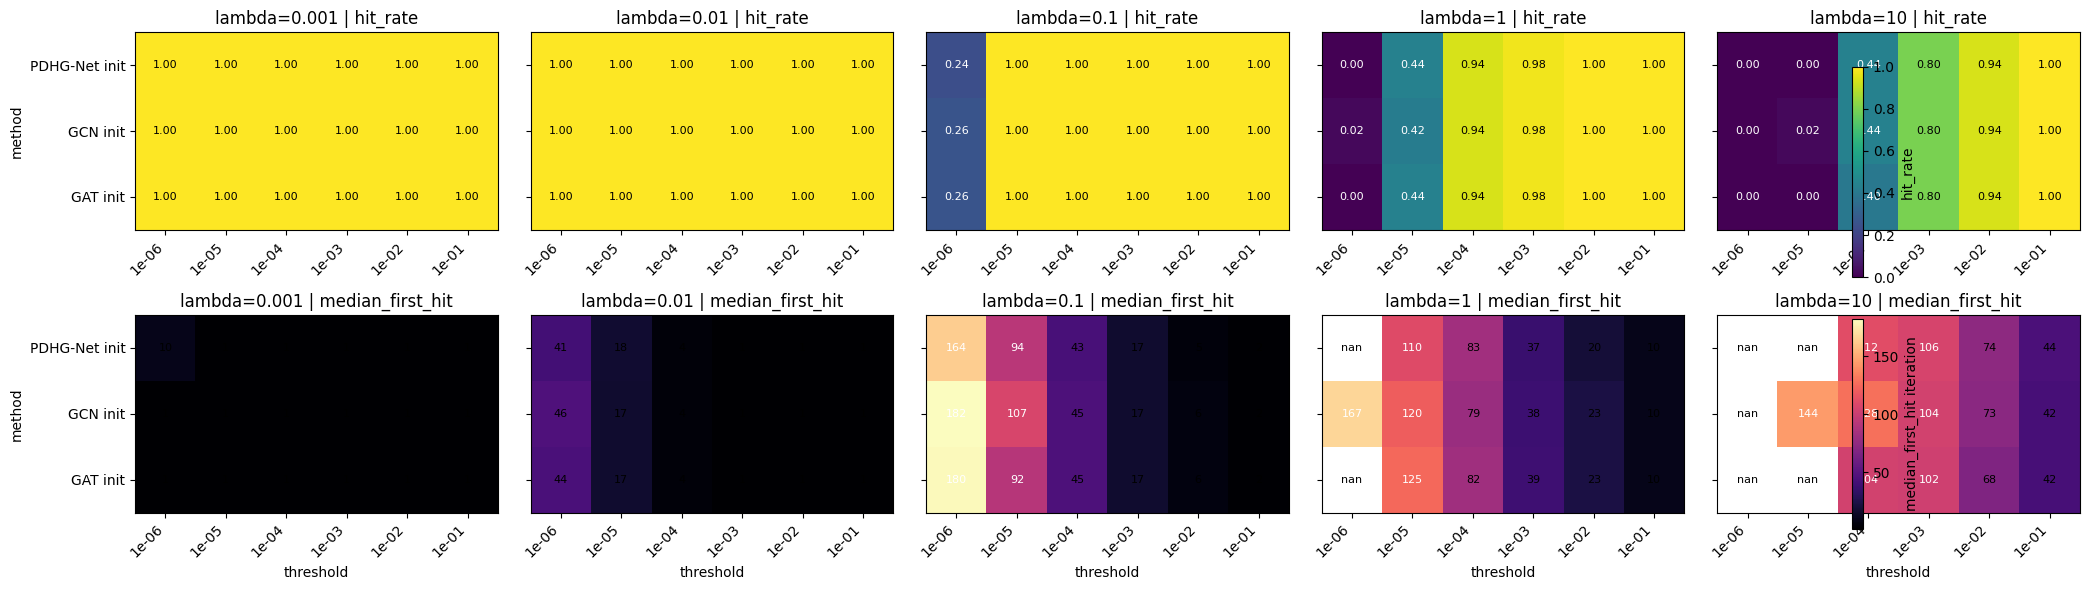

In [9]:
# Compact per-lambda summary plots: hit_rate + median_first_hit across thresholds
plot_methods = ['pdhg', 'gcn', 'gat']  # learned baselines + PDHG-Net
plot_df = threshold_summary[threshold_summary['method'].isin(plot_methods)].copy()

if plot_df.empty:
    raise RuntimeError('No rows available for selected plot_methods.')

method_order = [METHOD_LABELS[m] for m in plot_methods]
threshold_order = sorted(plot_df['threshold'].unique())
lambda_order = sorted(plot_df['lambda'].unique())

hit_vmin, hit_vmax = 0.0, 1.0
med_vmax = float(np.nanmax(plot_df['median_first_hit'].values)) if np.isfinite(plot_df['median_first_hit'].values).any() else 1.0
med_vmin = 1.0

fig, axes = plt.subplots(
    2,
    len(lambda_order),
    figsize=(4.2 * len(lambda_order), 6.0),
    squeeze=False,
)

for j, lam in enumerate(lambda_order):
    sub = plot_df[plot_df['lambda'] == lam]

    hit_mat = (
        sub.pivot_table(index='label', columns='threshold', values='hit_rate')
        .reindex(index=method_order, columns=threshold_order)
    )
    med_mat = (
        sub.pivot_table(index='label', columns='threshold', values='median_first_hit')
        .reindex(index=method_order, columns=threshold_order)
    )

    ax_hit = axes[0, j]
    im_hit = ax_hit.imshow(hit_mat.values, aspect='auto', cmap='viridis', vmin=hit_vmin, vmax=hit_vmax)
    ax_hit.set_title(f'lambda={lam:g} | hit_rate')
    ax_hit.set_xticks(np.arange(len(threshold_order)))
    ax_hit.set_xticklabels([f'{t:.0e}' for t in threshold_order], rotation=45, ha='right')
    ax_hit.set_yticks(np.arange(len(method_order)))
    ax_hit.set_yticklabels(method_order if j == 0 else [])

    for r in range(hit_mat.shape[0]):
        for c in range(hit_mat.shape[1]):
            v = hit_mat.values[r, c]
            txt = 'nan' if not np.isfinite(v) else f'{v:.2f}'
            ax_hit.text(c, r, txt, ha='center', va='center', color='white' if np.isfinite(v) and v < 0.55 else 'black', fontsize=8)

    ax_med = axes[1, j]
    im_med = ax_med.imshow(med_mat.values, aspect='auto', cmap='magma', vmin=med_vmin, vmax=med_vmax)
    ax_med.set_title(f'lambda={lam:g} | median_first_hit')
    ax_med.set_xticks(np.arange(len(threshold_order)))
    ax_med.set_xticklabels([f'{t:.0e}' for t in threshold_order], rotation=45, ha='right')
    ax_med.set_yticks(np.arange(len(method_order)))
    ax_med.set_yticklabels(method_order if j == 0 else [])

    for r in range(med_mat.shape[0]):
        for c in range(med_mat.shape[1]):
            v = med_mat.values[r, c]
            txt = 'nan' if not np.isfinite(v) else f'{v:.0f}'
            ax_med.text(c, r, txt, ha='center', va='center', color='white' if np.isfinite(v) and v > (0.5 * med_vmax) else 'black', fontsize=8)

fig.colorbar(im_hit, ax=axes[0, :].ravel().tolist(), fraction=0.02, pad=0.02, label='hit_rate')
fig.colorbar(im_med, ax=axes[1, :].ravel().tolist(), fraction=0.02, pad=0.02, label='median_first_hit iteration')

axes[1, 0].set_ylabel('method')
axes[0, 0].set_ylabel('method')
for ax in axes[1, :]:
    ax.set_xlabel('threshold')

plt.tight_layout()
plt.show()
